In [1]:
import pandas as pd
import numpy as np 
import os
from pathlib import Path  
import re

In [2]:
data_path = Path("../data/brats-ped")
mri_data = Path("/mnt/disk1/datasets/BraTS-PEDs")

data_path.exists() and mri_data.exists()

True

In [3]:
with_os_cohort = pd.read_csv(data_path / "cohort_with_OS.csv")

In [4]:
with_os_cohort.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0.1             116 non-null    int64  
 1   Unnamed: 0               116 non-null    int64  
 2   BraTS-SubjectID          116 non-null    object 
 3   MappingID                80 non-null     object 
 4   Source                   116 non-null    object 
 5   BraTS2025_cohort         116 non-null    object 
 6   Organization             116 non-null    object 
 7   Age at imaging (days)    116 non-null    float64
 8   Sex_at_birth             116 non-null    object 
 9   Ethnicity                116 non-null    object 
 10  Race                     116 non-null    object 
 11  Overall survival (days)  116 non-null    object 
dtypes: float64(1), int64(2), object(9)
memory usage: 11.0+ KB


In [5]:
# Check if all modalities are present
# should have seg, t1n, t2w, t1c and t2f
check = {}

for subject in with_os_cohort['BraTS-SubjectID'].unique():
    items = os.listdir(mri_data / "Training"/ subject)
    check[subject] = {"seg": False, "t1n": False, "t2w": False, "t1c": False, "t2f": False}
    for file in items:
        # format: <subject>-<modality>.nii.gz
        mod = file.split("-")[-1].split(".")[0]
        check[subject][mod] = True


In [6]:
for sub, modalities in check.items():
    if False in modalities.values():
        print(sub, "has missing modalities")

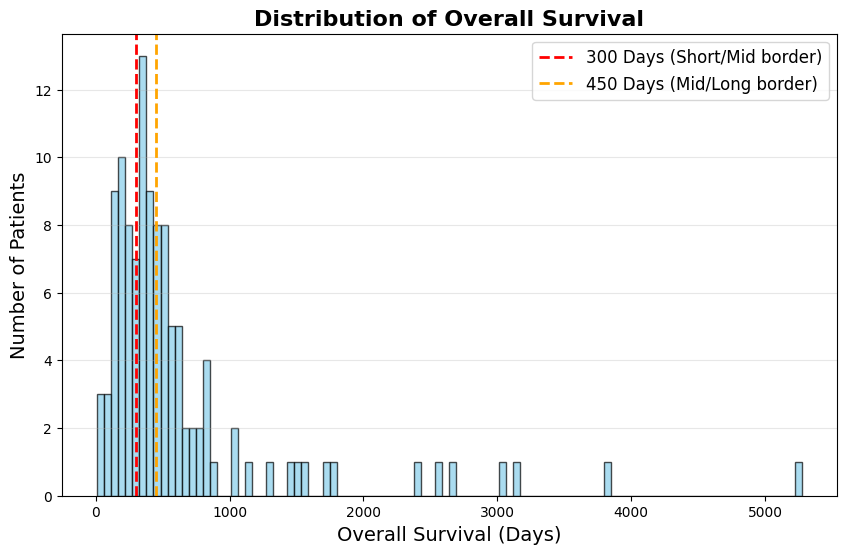

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filter out the "Not provided" strings
valid_survival_data = with_os_cohort[with_os_cohort["Overall survival (days)"] != "Not provided"]

# 2. Convert the remaining valid days to numeric values 
# (errors='coerce' will safely turn any other unexpected strings into NaN)
survival_days = pd.to_numeric(valid_survival_data["Overall survival (days)"], errors='coerce').dropna()

plt.figure(figsize=(10, 6))

# Plot the histogram
# We can use the integer values now
plt.hist(survival_days, bins=100, color='skyblue', edgecolor='black', alpha=0.7)

# Add vertical thresholds for the BraTS short/mid/long term stratification
plt.axvline(x=300, color='red', linestyle='--', linewidth=2, label='300 Days (Short/Mid border)')
plt.axvline(x=450, color='orange', linestyle='--', linewidth=2, label='450 Days (Mid/Long border)')

# Styling the plot
plt.title('Distribution of Overall Survival', fontsize=16, fontweight='bold')
plt.xlabel('Overall Survival (Days)', fontsize=14)
plt.ylabel('Number of Patients', fontsize=14)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Display the plot
plt.show()


In [18]:
import pandas as pd
import numpy as np

# 1. Convert to numeric (forces 'Not provided' to NaN)
os_days_numeric = pd.to_numeric(with_os_cohort["Overall survival (days)"], errors='coerce')

# 2. Assign classes based on the 300/450 thresholds
with_os_cohort["OS_class"] = pd.cut(
    os_days_numeric, 
    bins=[-np.inf, 300, 450, np.inf], 
    labels=[0, 1, 2], 
    right=False
)

# 3. Right-censor 'Not provided' (NaNs) by filling them with class 2 (Long-term)
# We cast to int at the end to clean it up for modeling
with_os_cohort["OS_class"] = with_os_cohort["OS_class"].fillna(2).astype(int)

In [19]:
with_os_cohort["OS_class"].value_counts()

OS_class
2    53
0    35
1    28
Name: count, dtype: int64

In [ ]:
with_os_cohort.to_csv(data_path / "cohort_with_OS_stratified.csv", index=None)